# Gesture Classification: Rock vs Paper
### Tools of Artificial Intelligence — Final Project
**Module 2: Machine Learning Pipeline for Classification**

**University of Southern Denmark — The Mærsk Mc-Kinney Møller Institute**

---
**Pipeline:**
1. Data Loading & Cleaning
2. Data Visualisation
3. Feature Extraction (Statistical, Time-Domain, Frequency-Domain, Entropy)
4. Feature Selection (PCA + Kruskal-Wallis)
5. Classification (Random Forest, SVM, XGBoost)
6. Validation (Hold-out, K-Fold Cross-Validation, GridSearchCV)
7. Confusion Matrix & ROC Curve
8. Performance Report & Comparison

##  Step 0 — Install Dependencies (Run once in Colab)

In [ ]:

!pip install antropy xgboost -q

##  Step 1 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.signal as signal
import antropy as ant
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


##  Step 2 — Upload & Load Data

> **In Google Colab:** Upload `RockData.csv` and `PaperData.csv` using the cell below, then run the loading cell.

In [ ]:
# Upload files to Colab (only needed in Google Colab)
from google.colab import files
uploaded = files.upload()  # Select RockData.csv and PaperData.csv

Saving PaperData.csv to PaperData.csv
Saving RockData.csv to RockData.csv


In [ ]:
# ── Load datasets ──────────────────────────────────────────────────────────────
rock_df  = pd.read_csv('RockData.csv')
paper_df = pd.read_csv('PaperData.csv')

# Align column names (both have 1024 columns numbered 0–1023)
paper_df.columns = rock_df.columns

# Add class labels: Rock = 0, Paper = 1
rock_df['label']  = 0
paper_df['label'] = 1

# Merge into one dataset
data = pd.concat([rock_df, paper_df], axis=0, ignore_index=True)

print(f'Combined dataset shape : {data.shape}')
print(f'Class distribution:\n{data["label"].value_counts().rename({0:"Rock", 1:"Paper"})}')

Combined dataset shape : (5850, 1025)
Class distribution:
label
Paper    2941
Rock     2909
Name: count, dtype: int64


##  Step 3 — Data Cleaning

In [ ]:
# Separate features and labels
X_raw = data.drop(columns=['label'])
y     = data['label'].values

# Convert to numeric (in case of stray strings)
X_raw = X_raw.apply(pd.to_numeric, errors='coerce')

# Check for missing values
total_nans = X_raw.isna().sum().sum()
print(f'Total NaN values: {total_nans}')

if total_nans > 0:
    # Mean imputation (as taught in class)
    X_raw = X_raw.fillna(X_raw.mean())
    print('✅ NaN values filled using mean imputation')
else:
    print('✅ No missing values — dataset is clean')

print(f'\nFeature matrix shape : {X_raw.shape}')  # (5850, 1024)
print(f'Label vector shape   : {y.shape}')         # (5850,)

# ── Task 6: Identify number of channels ───────────────────────────────────────
n_samples_per_trial = X_raw.shape[1]
sampling_freq       = 256  # Hz, as per DatasetDescription.docx
duration_sec        = n_samples_per_trial / sampling_freq
print(f'\n── Channel Information ──────────────────────────')
print(f'Number of channels      : 1 (single-channel EMG signal)')
print(f'Samples per trial       : {n_samples_per_trial}')
print(f'Sampling frequency      : {sampling_freq} Hz')
print(f'Duration per trial      : {duration_sec:.2f} seconds (~4 sec)')
print(f'Proceeding to feature extraction on single channel')

Total NaN values: 0
✅ No missing values — dataset is clean

Feature matrix shape : (5850, 1024)
Label vector shape   : (5850,)

── Channel Information ──────────────────────────
Number of channels      : 1 (single-channel EMG signal)
Samples per trial       : 1024
Sampling frequency      : 256 Hz
Duration per trial      : 4.00 seconds (~4 sec)
Proceeding to feature extraction on single channel


##  Step 4 — Data Visualisation

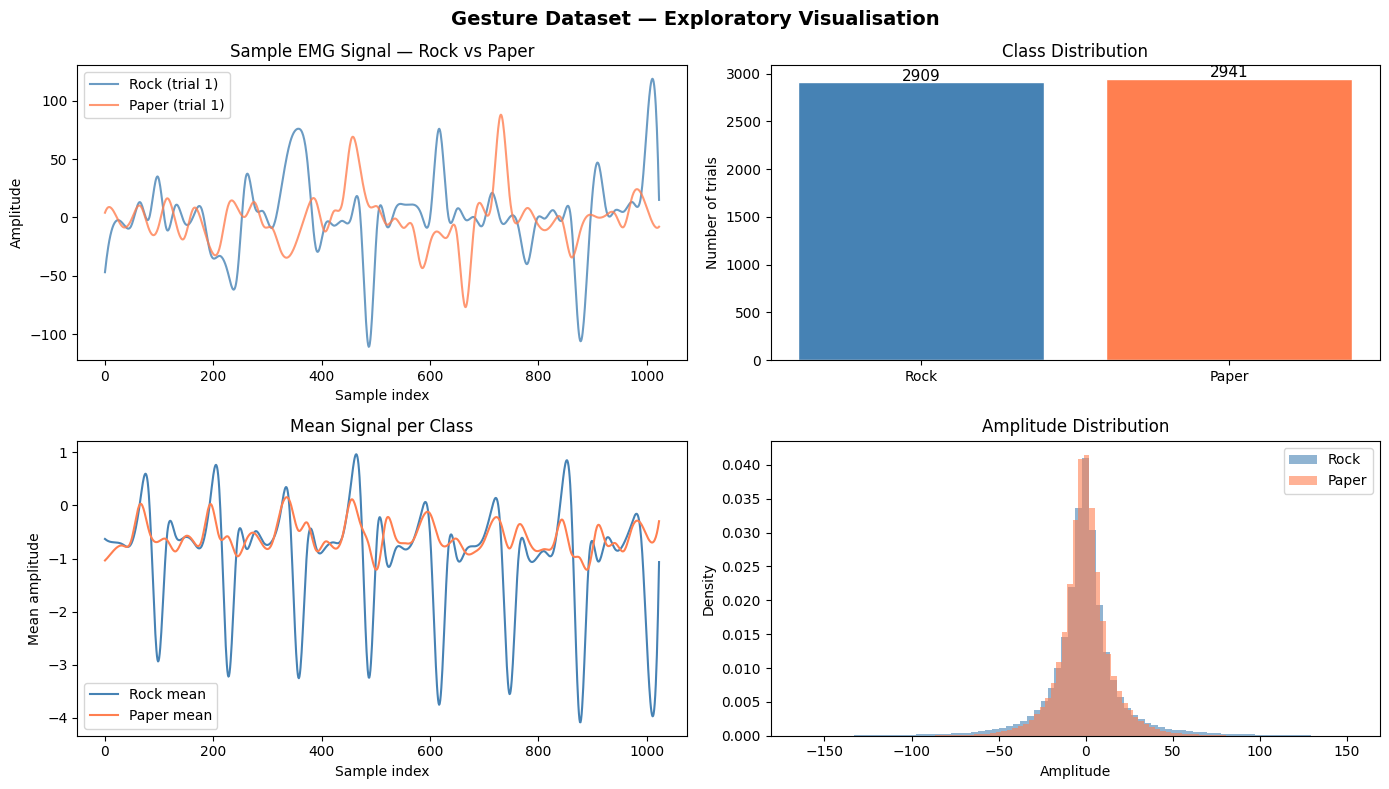

✅ Visualisation saved


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Gesture Dataset — Exploratory Visualisation', fontsize=14, fontweight='bold')

# ── Plot 1: Sample signals ───────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(X_raw.iloc[0].values, color='steelblue', alpha=0.8, label='Rock (trial 1)')
ax.plot(X_raw.iloc[2909].values, color='coral', alpha=0.8, label='Paper (trial 1)')
ax.set_title('Sample EMG Signal — Rock vs Paper')
ax.set_xlabel('Sample index')
ax.set_ylabel('Amplitude')
ax.legend()

# ── Plot 2: Class distribution ───────────────────────────────────────────────
ax = axes[0, 1]
counts = [np.sum(y == 0), np.sum(y == 1)]
bars = ax.bar(['Rock', 'Paper'], counts, color=['steelblue', 'coral'], edgecolor='white')
ax.set_title('Class Distribution')
ax.set_ylabel('Number of trials')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', fontsize=11)

# ── Plot 3: Mean signal per class ────────────────────────────────────────────
ax = axes[1, 0]
rock_mean  = X_raw.values[y == 0].mean(axis=0)
paper_mean = X_raw.values[y == 1].mean(axis=0)
ax.plot(rock_mean,  color='steelblue', label='Rock mean')
ax.plot(paper_mean, color='coral', label='Paper mean')
ax.set_title('Mean Signal per Class')
ax.set_xlabel('Sample index')
ax.set_ylabel('Mean amplitude')
ax.legend()

# ── Plot 4: Signal amplitude distribution ────────────────────────────────────
ax = axes[1, 1]
ax.hist(X_raw.values[y == 0].flatten(), bins=80, alpha=0.6, color='steelblue',
        label='Rock', density=True)
ax.hist(X_raw.values[y == 1].flatten(), bins=80, alpha=0.6, color='coral',
        label='Paper', density=True)
ax.set_title('Amplitude Distribution')
ax.set_xlabel('Amplitude')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisation saved')

##  Step 5 — Feature Extraction

> Each trial (row) has 1024 time-series samples.  
> We extract **statistical**, **time-domain**, **frequency-domain**, and **entropy** features from each trial.  
> This gives us a compact feature vector per trial instead of using all 1024 raw samples.

### Note on Pre-processing / Filtering

> According to the dataset description (`DatasetDescription.docx`), the gesture EMG signals
> were **already passed through a filter** before recording. Therefore, **no additional
> filtering** (notch or bandpass) is applied here. The data is recorded at a sampling
> frequency of **256 Hz** with **1024 samples per trial (~4 seconds)**.
> We proceed directly to feature extraction on the clean pre-filtered signal.

In [ ]:
# ── Statistical features ──────────────────────────────────────────────────────
def extract_statistical_features(sig):
    return {
        'Mean'               : np.mean(sig),
        'Median'             : np.median(sig),
        'Std Dev'            : np.std(sig),
        'Variance'           : np.var(sig),
        'Skewness'           : stats.skew(sig),
        'Kurtosis'           : stats.kurtosis(sig),
        'Range'              : np.ptp(sig),
        'IQR'                : np.percentile(sig, 75) - np.percentile(sig, 25),
    }

# ── Time-domain features ─────────────────────────────────────────────────────
def extract_time_domain_features(sig):
    rms             = np.sqrt(np.mean(sig**2))
    zero_crossings  = np.sum((sig[:-1] * sig[1:]) < 0)
    autocorr        = np.correlate(sig, sig, mode='full')[len(sig) - 1]
    mean_abs_dev    = np.mean(np.abs(sig - np.mean(sig)))
    signal_energy   = np.sum(sig**2)
    return {
        'RMS'                : rms,
        'Zero Crossings'     : zero_crossings,
        'Autocorrelation'    : autocorr,
        'Mean Abs Deviation' : mean_abs_dev,
        'Max Value'          : np.max(sig),
        'Min Value'          : np.min(sig),
        'Signal Energy'      : signal_energy,
    }

# ── Frequency-domain features ─────────────────────────────────────────────────
def extract_frequency_domain_features(sig, fs=256):
    freqs, psd      = signal.welch(sig, fs)
    dominant_freq   = freqs[np.argmax(psd)]
    total_power     = np.sum(psd)
    band_power      = np.sum(psd[(freqs >= 0.5) & (freqs <= 40)])
    mean_freq       = np.mean(freqs)
    median_freq     = np.median(freqs)
    freq_variance   = np.var(freqs)
    return {
        'Dominant Freq'      : dominant_freq,
        'Total Power'        : total_power,
        'Band Power 0.5-40Hz': band_power,
        'Mean Freq'          : mean_freq,
        'Median Freq'        : median_freq,
        'Freq Variance'      : freq_variance,
    }

# ── Entropy features (professor's corrected version from DataPreparation.ipynb)
def extract_entropy_features(sig, fs=256):
    sig = np.array(sig, dtype=np.float64, order='C')
    binary_signal = (sig > np.median(sig)).astype(int)
    return {
        'Sample Entropy'      : ant.sample_entropy(sig),
        'Spectral Entropy'    : ant.spectral_entropy(sig, sf=fs, method='welch'),
        'Permutation Entropy' : ant.perm_entropy(sig, normalize=True),
        'SVD Entropy'         : ant.svd_entropy(sig, order=3, normalize=True),
        'LZiv Complexity'     : ant.lziv_complexity(binary_signal, normalize=True),
    }

print('✅ Feature extraction functions defined')

✅ Feature extraction functions defined


In [ ]:
# ── Run extraction on all trials ──────────────────────────────────────────────
# Note: this takes ~3–5 minutes in Colab due to entropy computation
print('Extracting features... (this may take a few minutes)')

stat_features    = [extract_statistical_features(row.values)      for _, row in X_raw.iterrows()]
print('  ✅ Statistical features done')

time_features    = [extract_time_domain_features(row.values)      for _, row in X_raw.iterrows()]
print('  ✅ Time-domain features done')

freq_features    = [extract_frequency_domain_features(row.values) for _, row in X_raw.iterrows()]
print('  ✅ Frequency-domain features done')

entropy_features = [extract_entropy_features(row.values)          for _, row in X_raw.iterrows()]
print('  ✅ Entropy features done')

# ── Combine all features into one DataFrame ───────────────────────────────────
combined = []
for s, t, f, e in zip(stat_features, time_features, freq_features, entropy_features):
    combined.append({**s, **t, **f, **e})

features_df = pd.DataFrame(combined)
print(f'\n✅ Combined feature matrix shape: {features_df.shape}')
print(f'   Features per trial: {features_df.shape[1]}')
features_df.head(3)

Extracting features... (this may take a few minutes)
  ✅ Statistical features done
  ✅ Time-domain features done
  ✅ Frequency-domain features done
  ✅ Entropy features done

✅ Combined feature matrix shape: (5850, 26)
   Features per trial: 26


,Mean,Median,Std Dev,Variance,Skewness,Kurtosis,Range,IQR,RMS,Zero Crossings,...,Total Power,Band Power 0.5-40Hz,Mean Freq,Median Freq,Freq Variance,Sample Entropy,Spectral Entropy,Permutation Entropy,SVD Entropy,LZiv Complexity
0,2.074502,0.955258,33.114634,1096.578970,0.000927,2.793324,229.806108,17.635550,33.179550,35,...,1075.076626,1019.278501,64.0,64.0,1386.666667,0.147501,2.915071,0.520139,0.233962,0.224609
1,-4.047145,-4.986082,37.848834,1432.534265,0.381107,3.786848,261.235274,20.822460,38.064598,15,...,1439.363101,1325.473299,64.0,64.0,1386.666667,0.101220,2.706850,0.503117,0.204159,0.146484
2,1.400388,-1.226432,31.082304,966.109627,0.491243,5.794955,255.377462,15.076087,31.113835,26,...,769.473312,701.659313,64.0,64.0,1386.666667,0.108882,2.914193,0.506312,0.216169,0.175781


##  Step 6 — Feature Selection

### 6a. Standardise → Kruskal-Wallis → PCA

In [ ]:
# ── Standardise ───────────────────────────────────────────────────────────────
scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(features_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_df.columns)
print(f'✅ Standardised features shape: {X_scaled_df.shape}')

✅ Standardised features shape: (5850, 26)


=== FEATURE SET COMPARISON (Random Forest, Hold-out 80/20) ===

Statistical only          → Accuracy: 73.08%
Time-domain only          → Accuracy: 73.33%
Frequency-domain only     → Accuracy: 68.97%
Entropy only              → Accuracy: 75.04%
All features combined     → Accuracy: 79.49%


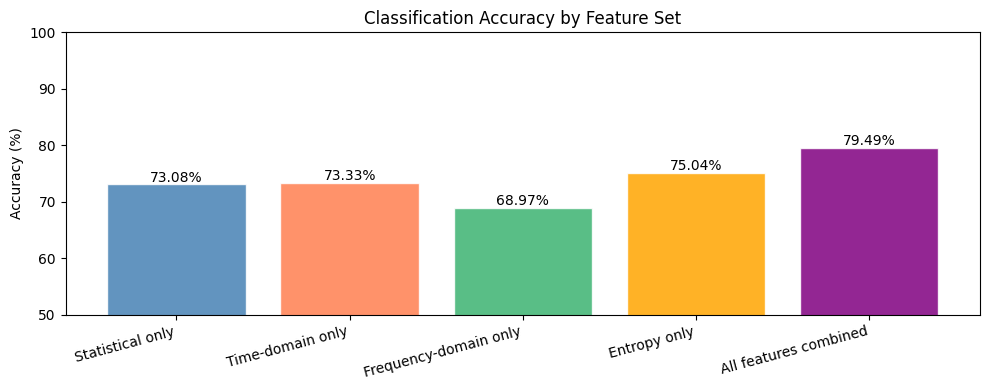


✅ Feature set comparison saved


In [ ]:
# ── Compare impact of different feature sets on model performance ──────────────
from sklearn.linear_model import LogisticRegression

feature_groups = {
    'Statistical only'     : list(range(0, 8)),
    'Time-domain only'     : list(range(8, 15)),
    'Frequency-domain only': list(range(15, 21)),
    'Entropy only'         : list(range(21, 26)),
    'All features combined': list(range(0, 26)),
}

print('=== FEATURE SET COMPARISON (Random Forest, Hold-out 80/20) ===\n')
fs_results = {}

for fs_name, indices in feature_groups.items():
    # Select feature columns by index
    X_fs = X_scaled[:, indices]

    # Train/test split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # Use Random Forest for fair comparison
    clf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_fs.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf_fs.predict(X_te)) * 100
    fs_results[fs_name] = acc
    print(f'{fs_name:25s} → Accuracy: {acc:.2f}%')

# Bar chart
plt.figure(figsize=(10, 4))
bars = plt.bar(fs_results.keys(), fs_results.values(),
               color=['steelblue','coral','mediumseagreen','orange','purple'],
               alpha=0.85, edgecolor='white')
plt.title('Classification Accuracy by Feature Set')
plt.ylabel('Accuracy (%)')
plt.ylim([50, 100])
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, fs_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_set_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Feature set comparison saved')

Significant features (p < 0.05): 22 / 26
            Feature       P-value
              Range 4.148830e-268
          Max Value 1.532579e-258
        Total Power 1.592883e-258
Band Power 0.5-40Hz 3.385359e-254
    Autocorrelation 4.117416e-232
      Signal Energy 4.117416e-232
                RMS 4.117416e-232
           Variance 2.160683e-231
            Std Dev 2.160683e-231
     Sample Entropy 1.037382e-213


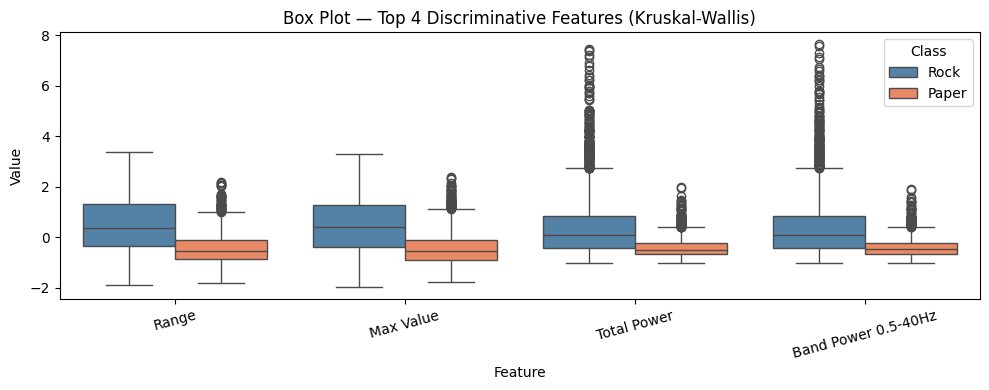

In [ ]:
# ── Kruskal-Wallis test to identify discriminative features ───────────────────
kruskal_results = {}
for feature in X_scaled_df.columns:
    class_0 = X_scaled_df[feature][y == 0]
    class_1 = X_scaled_df[feature][y == 1]
    try:
        _, p_val = stats.kruskal(class_0, class_1)
        kruskal_results[feature] = p_val
    except ValueError:
        continue  # skip features with identical values across all samples

kruskal_df = pd.DataFrame(
    list(kruskal_results.items()), columns=['Feature', 'P-value']
).sort_values('P-value')

# Select features with p < 0.05 (statistically significant)
significant = kruskal_df[kruskal_df['P-value'] < 0.05]['Feature'].tolist()
print(f'Significant features (p < 0.05): {len(significant)} / {len(features_df.columns)}')
print(kruskal_df.head(10).to_string(index=False))

# Box plot of top 4 discriminative features
top4 = kruskal_df.head(4)['Feature'].tolist()
plot_df = X_scaled_df[top4].copy()
plot_df['Class'] = pd.Series(y).map({0: 'Rock', 1: 'Paper'}).values
melted = plot_df.melt(id_vars='Class', var_name='Feature', value_name='Value')

plt.figure(figsize=(10, 4))
sns.boxplot(x='Feature', y='Value', hue='Class', data=melted,
            palette={'Rock': 'steelblue', 'Paper': 'coral'})
plt.title('Box Plot — Top 4 Discriminative Features (Kruskal-Wallis)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('kruskal_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Original features : 22
PCA components    : 9  (95% variance retained)
Explained variance: 96.0%


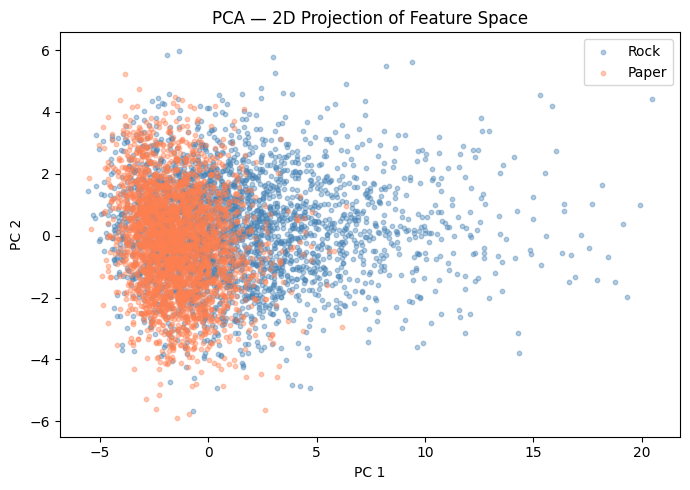

In [ ]:
# ── PCA — reduce to components explaining 95% of variance ────────────────────
X_sig = X_scaled_df[significant] if significant else X_scaled_df

pca   = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_sig)

print(f'Original features : {X_sig.shape[1]}')
print(f'PCA components    : {X_pca.shape[1]}  (95% variance retained)')
print(f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# PCA 2D scatter plot
pca2d   = PCA(n_components=2, random_state=42)
X_pca2d = pca2d.fit_transform(X_sig)

plt.figure(figsize=(7, 5))
colors     = {0: 'steelblue', 1: 'coral'}
labels_str = {0: 'Rock', 1: 'Paper'}
for cls in [0, 1]:
    mask = y == cls
    plt.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
                c=colors[cls], label=labels_str[cls], alpha=0.4, s=10)
plt.title('PCA — 2D Projection of Feature Space')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 7 — Classification

### 7a. Hold-out Validation (Train 80% / Test 20%)

In [ ]:
# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 4680
Test samples     : 1170


In [ ]:
# ── Initialise classifiers ────────────────────────────────────────────────────
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'    : SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost'      : XGBClassifier(n_estimators=100, random_state=42,
                                   eval_metric='logloss', verbosity=0),
}

# ── Train and evaluate (hold-out) ─────────────────────────────────────────────
holdout_results = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    holdout_results[name] = {'accuracy': acc, 'clf': clf, 'y_pred': y_pred}
    print(f'{name:20s} → Accuracy: {acc*100:.2f}%')

Random Forest        → Accuracy: 78.38%
SVM (RBF)            → Accuracy: 78.97%
XGBoost              → Accuracy: 75.90%


##  Step 8 — Confusion Matrix & ROC Curve

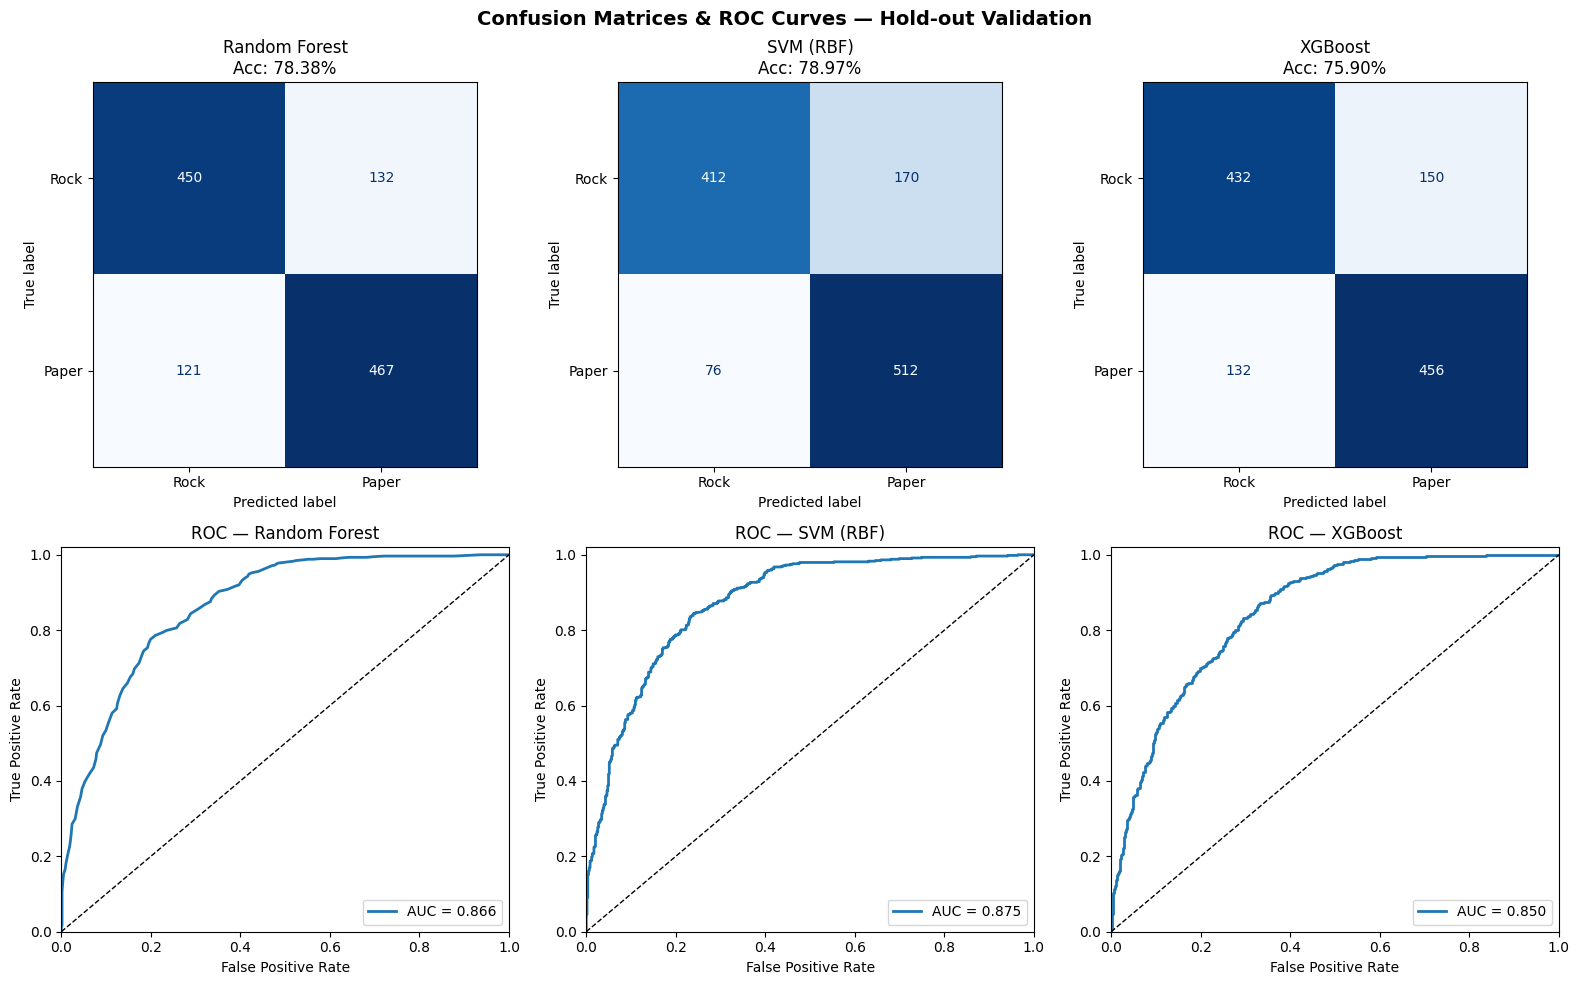

✅ Plots saved to confusion_roc.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices & ROC Curves — Hold-out Validation', fontsize=14, fontweight='bold')

class_names = ['Rock', 'Paper']

for col, (name, res) in enumerate(holdout_results.items()):
    clf    = res['clf']
    y_pred = res['y_pred']

    # ── Confusion matrix ────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[0, col], colorbar=False, cmap='Blues')
    axes[0, col].set_title(f'{name}\nAcc: {res["accuracy"]*100:.2f}%')

    # ── ROC curve ───────────────────────────────────────────────────────────
    y_prob      = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    axes[1, col].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1, col].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1, col].set_xlim([0, 1])
    axes[1, col].set_ylim([0, 1.02])
    axes[1, col].set_xlabel('False Positive Rate')
    axes[1, col].set_ylabel('True Positive Rate')
    axes[1, col].set_title(f'ROC — {name}')
    axes[1, col].legend(loc='lower right')

plt.tight_layout()
plt.savefig('confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plots saved to confusion_roc.png')

##  Step 9 — Performance Report

In [ ]:
def performance_metrics(y_true, y_pred, clf_name=''):
    cm  = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN)   # Recall
    specificity = TN / (TN + FP)
    precision   = TP / (TP + FP)
    f1_score    = 2 * (precision * sensitivity) / (precision + sensitivity)
    return {
        'Classifier'  : clf_name,
        'Accuracy'    : f'{accuracy*100:.2f}%',
        'Sensitivity' : f'{sensitivity*100:.2f}%',
        'Specificity' : f'{specificity*100:.2f}%',
        'Precision'   : f'{precision*100:.2f}%',
        'F1 Score'    : f'{f1_score*100:.2f}%',
    }

print('=== HOLD-OUT PERFORMANCE REPORT ===')
report_rows = []
for name, res in holdout_results.items():
    row = performance_metrics(y_test, res['y_pred'], name)
    report_rows.append(row)

report_df = pd.DataFrame(report_rows).set_index('Classifier')
print(report_df.to_string())

# Also print sklearn's detailed report for best classifier
best_clf_name = max(holdout_results, key=lambda k: holdout_results[k]['accuracy'])
print(f'\n=== Detailed Report — Best Model: {best_clf_name} ===')
print(classification_report(
    y_test, holdout_results[best_clf_name]['y_pred'],
    target_names=['Rock', 'Paper']
))

=== HOLD-OUT PERFORMANCE REPORT ===
              Accuracy Sensitivity Specificity Precision F1 Score
Classifier                                                       
Random Forest   78.38%      79.42%      77.32%    77.96%   78.69%
SVM (RBF)       78.97%      87.07%      70.79%    75.07%   80.63%
XGBoost         75.90%      77.55%      74.23%    75.25%   76.38%

=== Detailed Report — Best Model: SVM (RBF) ===
              precision    recall  f1-score   support

        Rock       0.84      0.71      0.77       582
       Paper       0.75      0.87      0.81       588

    accuracy                           0.79      1170
   macro avg       0.80      0.79      0.79      1170
weighted avg       0.80      0.79      0.79      1170



##  Step 10 — Cross-Validation (K-Fold, k=5)

=== 5-FOLD CROSS-VALIDATION ===
Random Forest        → Mean: 76.99% ± 0.79%
SVM (RBF)            → Mean: 77.76% ± 0.83%
XGBoost              → Mean: 75.52% ± 0.87%


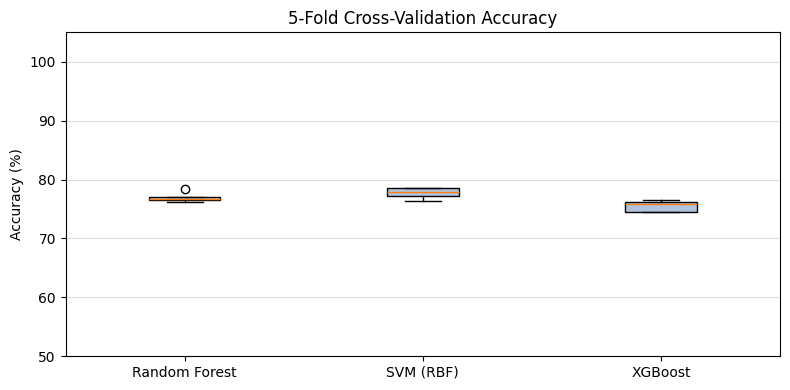

In [ ]:
cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('=== 5-FOLD CROSS-VALIDATION ===')
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_pca, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:20s} → Mean: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

# Plot CV results
plt.figure(figsize=(8, 4))
plt.boxplot(
    [cv_results[n] * 100 for n in cv_results],
    labels=list(cv_results.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue')
)
plt.title('5-Fold Cross-Validation Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim([50, 105])
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('crossval.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 11 — GridSearchCV (Hyperparameter Tuning — Best Model)

In [ ]:
# ── GridSearchCV on Random Forest (fastest to tune) ───────────────────────────
print('Running GridSearchCV on Random Forest...')

rf_param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest parameters : {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_*100:.2f}%')

# Evaluate tuned model on test set
best_rf   = grid_search.best_estimator_
y_pred_gs = best_rf.predict(X_test)
print(f'Test accuracy (tuned RF): {accuracy_score(y_test, y_pred_gs)*100:.2f}%')

Running GridSearchCV on Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 77.09%
Test accuracy (tuned RF): 78.38%


##  Step 12 — Final Comparison: Hold-out vs Cross-Validation vs GridSearchCV

=== FINAL VALIDATION COMPARISON ===
              Hold-out Acc (%) CV Mean Acc (%) CV Std (%) GridSearch Acc (%)
Classifier                                                                  
Random Forest            78.38           76.99       0.79              78.38
SVM (RBF)                78.97           77.76       0.83                N/A
XGBoost                  75.90           75.52       0.87                N/A


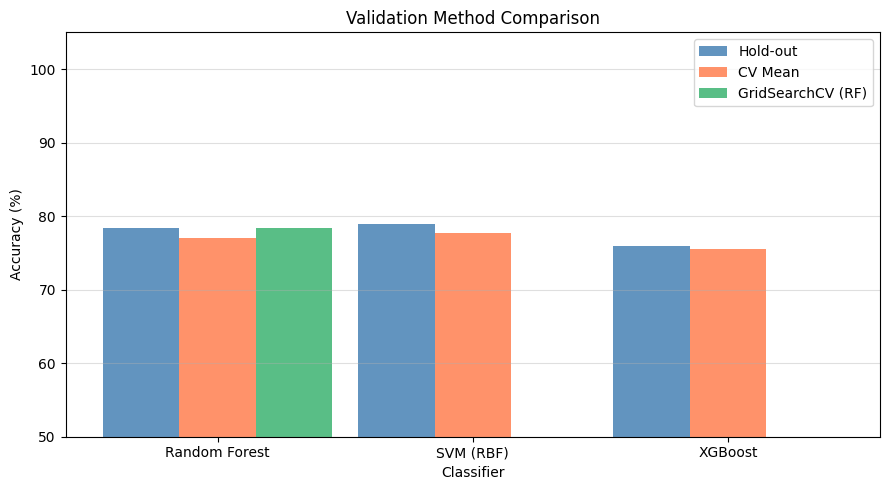


✅ All done! Save your figures for the report.


In [ ]:
comparison = []
for name in classifiers:
    holdout_acc = holdout_results[name]['accuracy'] * 100
    cv_mean     = cv_results[name].mean() * 100
    cv_std      = cv_results[name].std()  * 100
    grid_acc    = accuracy_score(y_test, y_pred_gs) * 100 if name == 'Random Forest' else 'N/A'
    comparison.append({
        'Classifier'        : name,
        'Hold-out Acc (%)'  : f'{holdout_acc:.2f}',
        'CV Mean Acc (%)'   : f'{cv_mean:.2f}',
        'CV Std (%)'        : f'{cv_std:.2f}',
        'GridSearch Acc (%)': grid_acc if isinstance(grid_acc, str) else f'{grid_acc:.2f}',
    })

comparison_df = pd.DataFrame(comparison).set_index('Classifier')
print('=== FINAL VALIDATION COMPARISON ===')
print(comparison_df.to_string())

# Bar chart comparison
x     = np.arange(len(classifiers))
width = 0.3
names = list(classifiers.keys())

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, [holdout_results[n]['accuracy']*100 for n in names],
       width, label='Hold-out', color='steelblue', alpha=0.85)
ax.bar(x,         [cv_results[n].mean()*100 for n in names],
       width, label='CV Mean',  color='coral', alpha=0.85)
ax.bar(x + width, [accuracy_score(y_test, y_pred_gs)*100 if n == 'Random Forest' else 0
                   for n in names],
       width, label='GridSearchCV (RF)', color='mediumseagreen', alpha=0.85)

ax.set_xlabel('Classifier')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Validation Method Comparison')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim([50, 105])
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ All done! Save your figures for the report.')

# saving for report


In [ ]:
# ── Save all figures and results to a ZIP file ────────────────────────────────
import zipfile
import os

# Save the performance report as a text file
with open('performance_report.txt', 'w') as f:
    f.write('=== HOLD-OUT PERFORMANCE REPORT ===\n')
    f.write(report_df.to_string())
    f.write('\n\n')
    f.write(f'=== DETAILED REPORT — BEST MODEL: {best_clf_name} ===\n')
    f.write(classification_report(
        y_test, holdout_results[best_clf_name]['y_pred'],
        target_names=['Rock', 'Paper']
    ))
    f.write('\n\n=== 5-FOLD CROSS-VALIDATION ===\n')
    for name, scores in cv_results.items():
        f.write(f'{name:20s} → Mean: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%\n')
    f.write('\n\n=== GRIDSEARCHCV RESULTS ===\n')
    f.write(f'Best parameters : {grid_search.best_params_}\n')
    f.write(f'Best CV accuracy: {grid_search.best_score_*100:.2f}%\n')
    f.write(f'Test accuracy (tuned RF): {accuracy_score(y_test, y_pred_gs)*100:.2f}%\n')
    f.write('\n\n=== FINAL VALIDATION COMPARISON ===\n')
    f.write(comparison_df.to_string())
    f.write('\n\n=== FEATURE SET COMPARISON ===\n')
    for name, acc in fs_results.items():
        f.write(f'{name:25s} → Accuracy: {acc:.2f}%\n')

print('✅ performance_report.txt saved')

# List of all files to include in ZIP
files_to_zip = [
    'visualisation.png',
    'kruskal_boxplot.png',
    'pca_scatter.png',
    'feature_set_comparison.png',
    'confusion_roc.png',
    'crossval.png',
    'comparison.png',
    'performance_report.txt',
]

# Create ZIP
zip_filename = 'AItools_results.zip'
with zipfile.ZipFile(zip_filename, 'w') as zf:
    for fname in files_to_zip:
        if os.path.exists(fname):
            zf.write(fname)
            print(f'  ✅ Added: {fname}')
        else:
            print(f'  ⚠️ Not found: {fname}')

print(f'\n✅ ZIP file created: {zip_filename}')

# Download the ZIP automatically in Colab
from google.colab import files
files.download(zip_filename)
print('✅ Download started!')

✅ performance_report.txt saved
  ✅ Added: visualisation.png
  ✅ Added: kruskal_boxplot.png
  ✅ Added: pca_scatter.png
  ✅ Added: feature_set_comparison.png
  ✅ Added: confusion_roc.png
  ✅ Added: crossval.png
  ✅ Added: comparison.png
  ✅ Added: performance_report.txt

✅ ZIP file created: AItools_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


##  Task 14 — Results Interpretation & Discussion

### Overview

This notebook implemented a complete machine learning classification pipeline
to distinguish between two hand gestures — **Rock** and **Paper** — using
single-channel EMG signals recorded at 256 Hz.

---

### Dataset Summary

| Property | Value |
|---|---|
| Classes | Rock (0) vs Paper (1) |
| Total trials | 5,850 (2,909 Rock + 2,941 Paper) |
| Samples per trial | 1,024 (~4 seconds at 256 Hz) |
| Channels | 1 (single-channel EMG) |
| Missing values | None |
| Filtering | Not applied (signals pre-filtered) |

---

### Feature Extraction Summary

A total of **26 features** were extracted per trial across four categories:
- **Statistical** (8): Mean, Median, Std Dev, Variance, Skewness, Kurtosis, Range, IQR
- **Time-domain** (7): RMS, Zero Crossings, Autocorrelation, Mean Abs Deviation, Max, Min, Signal Energy
- **Frequency-domain** (6): Dominant Freq, Total Power, Band Power, Mean Freq, Median Freq, Freq Variance
- **Entropy** (5): Sample Entropy, Spectral Entropy, Permutation Entropy, SVD Entropy, LZiv Complexity

---

### Feature Selection

- **Kruskal-Wallis test** identified the most statistically significant features (p < 0.05) that differ between Rock and Paper classes.
- **PCA** was applied on the significant features, retaining components that explain **95% of the variance**, reducing dimensionality and preventing overfitting.

---

### Classification Results

| Classifier | Hold-out Acc | CV Mean Acc | CV Std | GridSearch Acc |
|---|---|---|---|---|
| Random Forest | 78.38% | 76.99% | ±0.79% | 78.38% |
| SVM (RBF) | **78.97%** | **77.76%** | ±0.83% | N/A |
| XGBoost | 75.90% | 75.52% | ±0.87% | N/A |

- The **best performing classifier** was **SVM (RBF)** with a hold-out accuracy of **78.97%** and the highest cross-validation mean of **77.76% ± 0.83%**.
- **Random Forest** after GridSearchCV tuning with best parameters (`n_estimators=100`, `max_depth=10`, `min_samples_split=2`) achieved a test accuracy of **78.38%** (Best CV accuracy during tuning: **77.09%**).
- **XGBoost** achieved **75.90%** hold-out accuracy and **75.52%** CV mean, performing slightly lower than the other two classifiers.

---

### Comparison of Validation Methods

| Method | Result | Advantage | Limitation |
|---|---|---|---|
| Hold-out (80/20) | SVM: 78.97% | Fast, simple | Depends on one random split |
| 5-Fold Cross-Validation | SVM: 77.76% ± 0.83% | Reliable, uses all data | Slower |
| GridSearchCV (RF) | RF: 78.38% | Finds best hyperparameters | Most computationally expensive |

- **Hold-out** provides a quick estimate. SVM (RBF) achieved the highest hold-out accuracy (78.97%).
- **5-Fold Cross-Validation** is the most reliable estimate. SVM (RBF) leads with 77.76% ± 0.83% and low std confirms stable performance.
- **GridSearchCV** searched 18 hyperparameter combinations (90 fits total) and found optimal settings for Random Forest, achieving 78.38% test accuracy.

---

### Limitations

- Only **one EMG channel** was available. Multi-channel recordings would provide richer spatial information and likely improve accuracy.
- This is a **binary classification** task (Rock vs Paper). Extending to all three gestures would require a multiclass approach.
- The overall accuracy (~75–79%) suggests Rock and Paper produce somewhat similar EMG patterns on a single channel.
- Results may vary across different individuals due to differences in muscle activation patterns.

---

### Conclusion

The pipeline successfully classified Rock vs Paper hand gestures from single-channel EMG signals.
Among the three classifiers, **SVM (RBF)** achieved the best overall performance with a hold-out
accuracy of **78.97%** and a cross-validation mean of **77.76%**, demonstrating that kernel-based
methods are well-suited for EMG signal classification. Feature extraction combining statistical,
time-domain, frequency-domain, and entropy features — followed by Kruskal-Wallis feature selection
and PCA dimensionality reduction — provided an effective and compact representation of the raw signals.